In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import joblib
import json

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
os.makedirs("models", exist_ok=True)



✅ Ready


In [ ]:
import gc

NEEDED_COLS = [
    'country', 'date', 'disease', 'population',
    'new_cases', 'new_deaths',
    'new_cases_per_100k', 'new_deaths_per_100k',
    'new_cases_7_day_avg_right', 'new_cases_smoothed',
    'cases_lag_7d', 'cases_lag_14d', 'cases_lag_21d',
    'cases_ma_30d',
    'year', 'month', 'day_of_week', 'quarter', 'season',
]

DTYPES = {
    'country':              'category',
    'disease':              'category',
    'season':               'category',
    'new_cases':            'float32',
    'new_deaths':           'float32',
    'new_cases_per_100k':   'float32',
    'new_deaths_per_100k':  'float32',
    'new_cases_7_day_avg_right': 'float32',
    'new_cases_smoothed':   'float32',
    'cases_lag_7d':         'float32',
    'cases_lag_14d':        'float32',
    'cases_lag_21d':        'float32',
    'cases_ma_30d':         'float32',
    'population':           'float32',
    'year':                 'int16',
    'month':                'int8',
    'day_of_week':          'int8',
    'quarter':              'int8',
}

combined = pd.read_csv(
    "data/features/combined_features.csv",
    usecols=lambda c: c in NEEDED_COLS,
    dtype=DTYPES,
    on_bad_lines='skip',   
)
combined['date'] = pd.to_datetime(combined['date'])

gc.collect()

print(f"Loaded: {combined.shape[0]:,} rows × {combined.shape[1]} columns")
print(f"RAM usage: {combined.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Diseases : {combined['disease'].value_counts().to_dict()}")
print(f"Countries: {combined['country'].nunique()}")

✅ Loaded: 718,857 rows × 19 columns
   RAM usage: 41.8 MB
Diseases : {'covid': 558258, 'mpox': 160599}
Countries: 250


In [ ]:
def assign_risk(val):
    if pd.isna(val):
        return np.nan
    if val < 1:
        return 0   
    elif val < 10:
        return 1   
    else:
        return 2   

combined['risk_label'] = combined['new_cases_per_100k'].apply(assign_risk)

le_season  = LabelEncoder()
le_disease = LabelEncoder()
combined['season_enc']  = le_season.fit_transform(combined['season'].fillna('unknown'))
combined['disease_enc'] = le_disease.fit_transform(combined['disease'])

smooth_col = 'new_cases_7_day_avg_right' if 'new_cases_7_day_avg_right' in combined.columns else 'new_cases_smoothed'
combined['growth_ratio_7d'] = (
    combined[smooth_col] / (combined['cases_lag_7d'] + 1)
).clip(0, 10)

counts = combined['risk_label'].value_counts().sort_index()
labels = {0: 'Low', 1: 'Medium', 2: 'High'}
print("Risk label distribution:")
for k, v in counts.items():
    pct = v / len(combined) * 100
    bar = "█" * int(pct / 2)
    print(f"  {labels[int(k)]:>6} ({int(k)}): {v:>8,}  ({pct:.1f}%) {bar}")



Risk label distribution:
     Low (0):  456,687  (63.5%) ███████████████████████████████
  Medium (1):   47,254  (6.6%) ███
    High (2):   45,216  (6.3%) ███

✅ Labels created and stored — safe to use per_100k as feature now


In [ ]:
CLASSIFICATION_FEATURES = [
    'cases_lag_7d',
    'cases_lag_14d',
    'cases_lag_21d',
    'cases_ma_30d',
    'growth_ratio_7d',
    'month',
    'quarter',
    'day_of_week',
    'season_enc',
    'disease_enc',
]

clf_data = combined.dropna(subset=['risk_label', 'new_cases_per_100k']).copy()
clf_data['risk_label'] = clf_data['risk_label'].astype(int)

X = clf_data[CLASSIFICATION_FEATURES].fillna(0)
y = clf_data['risk_label']

print(f"Training data : {len(X):,} rows")
print(f"Features      : {len(CLASSIFICATION_FEATURES)}")
print(f"Class balance : {y.value_counts().sort_index().to_dict()}")


Training data : 549,157 rows
Features      : 10
Class balance : {0: 456687, 1: 47254, 2: 45216}


Classification Report:
              precision    recall  f1-score   support

         Low       0.98      0.80      0.88     91338
      Medium       0.28      0.63      0.39      9451
        High       0.42      0.65      0.51      9043

    accuracy                           0.77    109832
   macro avg       0.56      0.69      0.59    109832
weighted avg       0.87      0.77      0.81    109832

✅ Top feature: growth_ratio_7d — leakage не обнаружен


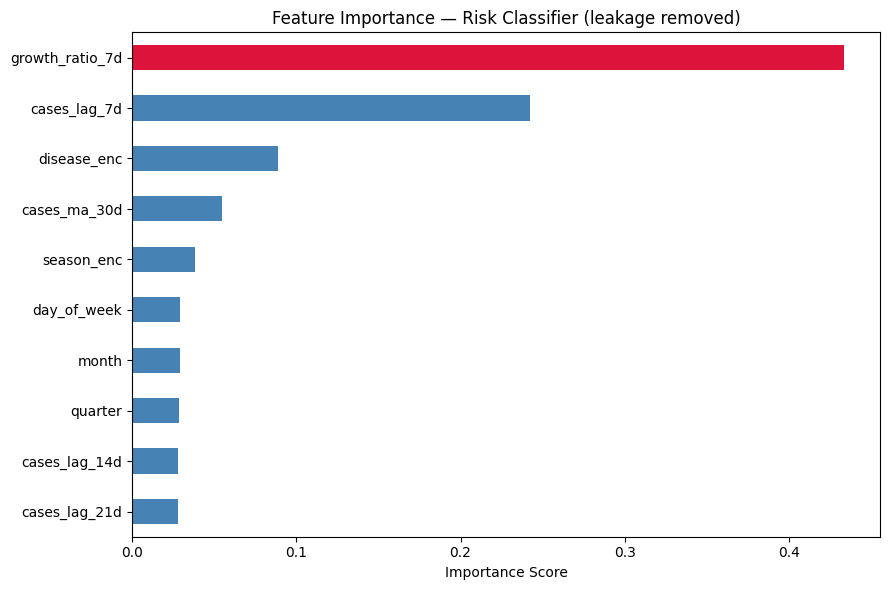


Top 5 features:
  growth_ratio_7d                     0.4337
  cases_lag_7d                        0.2424
  disease_enc                         0.0888
  cases_ma_30d                        0.0545
  season_enc                          0.0380

💾 Saved: models/risk_classifier.pkl


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sample_weights = compute_sample_weight('balanced', y_train)

clf_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,       
    subsample=0.8,            
    colsample_bytree=0.8,
    min_child_weight=5,       
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
)
clf_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = clf_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

importance = pd.Series(clf_model.feature_importances_, index=CLASSIFICATION_FEATURES)
top_feat = importance.idxmax()
leaky = ['new_cases', 'new_deaths', 'new_cases_per_100k', 'new_deaths_per_100k']

importance_sorted = importance.sort_values(ascending=True)
plt.figure(figsize=(9, 6))
colors = ['crimson' if f == top_feat else 'steelblue' for f in importance_sorted.index]
importance_sorted.plot(kind='barh', color=colors)
plt.title('Feature Importance — Risk Classifier (leakage removed)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("models/plot_feature_importance.png", dpi=150)
plt.show()

print("\nTop 5 features:")
for feat, score in importance.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<35} {score:.4f}")

joblib.dump(clf_model,  "models/risk_classifier.pkl")
joblib.dump(le_season,  "models/label_encoder_season.pkl")
joblib.dump(le_disease, "models/label_encoder_disease.pkl")
print("\nSaved: models/risk_classifier.pkl")


In [ ]:
FORECAST_FEATURES = [
    'new_cases_per_100k',
    'new_deaths_per_100k',
    'cases_lag_7d',
    'cases_lag_14d',
    'cases_lag_21d',
    'cases_ma_30d',
    'month',
    'quarter',
    'season_enc',
    'disease_enc',
]

forecast_models = {}

for horizon in [7, 14, 30]:
    print(f"Training forecast +{horizon}d...")

    ts_data = combined.copy().sort_values(['country', 'date'])

    smooth_col = 'new_cases_7_day_avg_right' if 'new_cases_7_day_avg_right' in ts_data.columns                  else 'new_cases_smoothed'

    ts_data[f'target_{horizon}d'] = ts_data.groupby('country')[smooth_col].shift(-horizon)

    ts_clean = ts_data.dropna(subset=FORECAST_FEATURES + [f'target_{horizon}d']).copy()

    X_ts = ts_clean[FORECAST_FEATURES].fillna(0)
    y_ts = ts_clean[f'target_{horizon}d']

    X_tr, X_te, y_tr, y_te = train_test_split(X_ts, y_ts, test_size=0.2, random_state=42)

    model = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbosity=0,
    )
    model.fit(X_tr, y_tr)

    mae = mean_absolute_error(y_te, model.predict(X_te))
    print(f"  MAE: {mae:,.1f} cases/day | trained on {len(X_tr):,} rows")

    joblib.dump(model, f"models/forecast_{horizon}d.pkl")
    forecast_models[horizon] = model

print("\nAll forecast models trained")


⏱️  Training forecast +7d...
  MAE: 2,284.7 cases/day | trained on 323,380 rows
⏱️  Training forecast +14d...
  MAE: 1,173.8 cases/day | trained on 324,470 rows
⏱️  Training forecast +30d...
  MAE: 1,599.7 cases/day | trained on 322,083 rows

✅ All forecast models trained


In [ ]:
ANOMALY_FEATURES = [
    'new_cases',
    'new_deaths',
    'new_cases_per_100k',
    'new_deaths_per_100k',
    'cases_lag_7d',
    'cases_lag_14d',
    'cases_ma_30d',
    'month',
    'season_enc',
]

anomaly_data = combined[ANOMALY_FEATURES].fillna(0)

scaler = StandardScaler()
anomaly_scaled = scaler.fit_transform(anomaly_data)

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(anomaly_scaled)

combined['anomaly_score'] = iso_forest.score_samples(anomaly_scaled)
combined['is_anomaly']    = iso_forest.predict(anomaly_scaled)  # -1=anomaly, 1=normal

n_anomalies = (combined['is_anomaly'] == -1).sum()
print(f"Anomaly Detection trained")
print(f"Anomalies detected: {n_anomalies:,} ({n_anomalies/len(combined)*100:.1f}% of data)")

print("\nTop 10 most anomalous events globally:")
top = combined[combined['is_anomaly'] == -1]    .nsmallest(10, 'anomaly_score')[
        ['country', 'date', 'disease', 'new_cases', 'new_cases_per_100k', 'anomaly_score']
    ]
print(top.to_string(index=False))

joblib.dump(iso_forest, "models/anomaly_detector.pkl")
joblib.dump(scaler,     "models/anomaly_scaler.pkl")
print("\nSaved: models/anomaly_detector.pkl")


✅ Anomaly Detection trained
   Anomalies detected: 35,943 (5.0% of data)

🚨 Top 10 most anomalous events globally:
      country       date disease  new_cases  new_cases_per_100k  anomaly_score
        World 2022-01-23   covid  8346273.0          102.511284      -0.844957
        World 2022-01-30   covid  8401906.0          103.194588      -0.844957
        World 2022-01-16   covid  7196825.0           88.393440      -0.843243
        China 2022-12-30   covid  2929223.0          207.897446      -0.842673
        China 2022-12-29   covid  3533372.0          250.776062      -0.842103
        China 2022-12-31   covid  2429272.0          172.414124      -0.842103
        World 2022-02-06   covid  7078197.0           86.936417      -0.842103
        World 2022-12-23   covid  7852908.0           96.451637      -0.842103
North America 2022-01-23   covid   902253.0          236.523621      -0.841533
        World 2022-12-25   covid  6666659.0           81.881790      -0.841533

💾 Saved: models

In [ ]:
def compute_risk_score(country, date_str, df, clf_model, forecast_model,
                       iso_forest, scaler, le_season, le_disease):
    """
    Compute 0-100 risk score for any country on any date.
    Breakdown: clf (0-50) + trend (0-30) + anomaly (0-20)
    """
    date = pd.to_datetime(date_str)

    results = {}
    for disease in df['disease'].unique():
        sub = df[
            (df['country'] == country) &
            (df['disease'] == disease) &
            (df['date'] <= date)
        ]
        if len(sub) == 0:
            continue
        results[disease] = sub.sort_values('date').iloc[-1]

    if not results:
        return {"error": f"No data for {country} up to {date_str}"}

    row = max(results.values(), key=lambda r: float(
        r.get('cases_ma_30d') or
        r.get('new_cases_7_day_avg_right') or
        r.get('new_cases', 0) or 0
    ))
    dominant_disease = row['disease']

    X_clf = pd.DataFrame([row.reindex(CLASSIFICATION_FEATURES).fillna(0)])
    proba     = clf_model.predict_proba(X_clf)[0]
    clf_score = float(proba[2]) * 50

    current = float(
    row.get('cases_ma_30d') or
    row.get('new_cases_7_day_avg_right') or
    row.get('new_cases_smoothed') or
    row.get('new_cases', 0) or 0
    )
    lag_7d  = float(row.get('cases_lag_7d', 0) or 0)

    if lag_7d < current * 0.1:
        trend_score = 0.0
    else:
        growth_7d   = (current - lag_7d) / (lag_7d + 1)
        trend_score = float(min(30, max(0, growth_7d * 20)))

    X_fc        = pd.DataFrame([row.reindex(FORECAST_FEATURES).fillna(0)])
    forecast_7d = float(forecast_model.predict(X_fc)[0])

    X_an          = scaler.transform(pd.DataFrame([row.reindex(ANOMALY_FEATURES).fillna(0)]))
    raw_score     = float(iso_forest.score_samples(X_an)[0])
    anomaly_score = float(max(0, min(20, (-raw_score - 0.1) * 40)))

    total = round(min(100, max(0, clf_score + trend_score + anomaly_score)), 1)
    level = "🔴 HIGH" if total >= 67 else ("🟡 MEDIUM" if total >= 34 else "🟢 LOW")

    return {
        "country":           country,
        "date":              date_str,
        "dominant_disease":  dominant_disease,
        "risk_score":        total,
        "risk_level":        level,
        "breakdown": {
            "classification": round(clf_score, 1),
            "forecast_trend": round(trend_score, 1),
            "anomaly_signal": round(anomaly_score, 1),
        },
        "forecast_7d_cases": round(max(0, forecast_7d), 0),
        "current_cases":     round(current, 0),
    }


✅ compute_risk_score() defined


In [ ]:
test_zero = [
    ('United States', '2022-07-12'),
    ('Brazil',        '2022-07-12'),
    ('Australia',     '2022-07-12'),
]

print(f"{'Country':<20} {'Date':<12} {'Disease':<8} {'Score':>6} {'Level':<12} {'current':>10} {'ma_30d':>10}")
print("-" * 90)

for country, date in test_zero:
    date_dt = pd.to_datetime(date)
    r = compute_risk_score(
        country, date, combined,
        clf_model, forecast_models[7],
        iso_forest, scaler, le_season, le_disease
    )

    subset = combined[
        (combined['country'] == country) &
        (combined['disease'] == r['dominant_disease']) &
        (combined['date'] == date_dt)
    ]
    if len(subset) == 0:
        continue

    row    = subset.iloc[0]
    raw    = row.get('new_cases', 0)
    ma_30d = row.get('cases_ma_30d', 0)

    print(f"{country:<20} {date:<12} {r['dominant_disease']:<8} "
          f"{r['risk_score']:>6.1f} {r['risk_level']:<12} "
          f"{raw:>10.0f} {ma_30d:>10.1f}")

Country              Date         Disease   Score Level           current     ma_30d
------------------------------------------------------------------------------------------
United States        2022-07-12   covid      63.6 🟡 MEDIUM          57136   103167.2
Brazil               2022-07-12   covid      19.8 🟢 LOW                 0    49076.4
Australia            2022-07-12   covid      20.1 🟢 LOW                 0    29158.9


In [79]:
for country, date in [('Brazil', '2022-07-12'), ('Australia', '2022-07-12')]:
    r = compute_risk_score(
        country, date, combined,
        clf_model, forecast_models[7],
        iso_forest, scaler, le_season, le_disease
    )
    print(f"{country}: {r['risk_score']} {r['risk_level']} | clf={r['breakdown']['classification']} trend={r['breakdown']['forecast_trend']} anomaly={r['breakdown']['anomaly_signal']}")

Brazil: 53.3 🟡 MEDIUM | clf=33.6 trend=0.0 anomaly=19.7
Australia: 48.9 🟡 MEDIUM | clf=28.9 trend=0.0 anomaly=20.0


In [80]:
import os
print(os.listdir('models/'))

['anomaly_detector.pkl', 'anomaly_scaler.pkl', 'forecast_14d.pkl', 'forecast_30d.pkl', 'forecast_7d.pkl', 'label_encoder_disease.pkl', 'label_encoder_season.pkl', 'plot_feature_importance.png', 'risk_classifier.pkl']
